<a href="https://colab.research.google.com/github/IQubaisi/Q-Trade/blob/main/DRL_QTrade_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INM707 Deep Reinforcement Learning — QTrade Agent
**City, University of London** | Tasks 1–8

---

Run cells **top to bottom**. Google Drive mounts once at the top — Q-tables and DQN weights save permanently so you never retrain unless you delete them from Drive.

## Setup — Run This First Every Session

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import random, os
from collections import deque
import yfinance as yf

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

SAVE_DIR = '/content/drive/MyDrive/DRL_CW'
os.makedirs(SAVE_DIR, exist_ok=True)
Q_PATH   = os.path.join(SAVE_DIR, 'q_table_base.npy')
DQN_PATH = os.path.join(SAVE_DIR, 'dqn_weights.pth')

print(f'Drive mounted. Saving to: {SAVE_DIR}')
print(f'Files on Drive: {os.listdir(SAVE_DIR)}')

Mounted at /content/drive
Drive mounted. Saving to: /content/drive/MyDrive/DRL_CW
Files on Drive: ['DRL_QTrade_Clean.ipynb', 'q_table_base.npy', 'fig1_msft_price.png', 'fig2_reward_matrix.png', 'fig3_transition.png', 'fig4_epsilon_decay.png', 'fig5_reward_base.png', 'fig6_alpha.png', 'fig7_gamma.png', 'fig8_decay.png', 'fig9_policy.png', 'fig10_all_experiments.png', 'fig11_agent_test.png', 'dqn_weights.pth', 'fig12_dqn_reward.png', 'fig13_ql_vs_dqn.png']


---
## Task 1: Define the Environment

In [2]:
df = yf.download('MSFT', start='2018-01-01', end='2023-12-31', progress=False)
df = df[['Close']].copy()
df.columns = ['Close']
df['price_change'] = df['Close'].diff()
df = df.dropna().reset_index()
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
print(f'Data loaded: {len(df)} trading days')
print(df.head())

/tmp/ipykernel_4539/1562592983.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('MSFT', start='2018-01-01', end='2023-12-31', progress=False)


Data loaded: 1508 trading days
        Date      Close  price_change
0 2018-01-03  79.237427      0.367058
1 2018-01-04  79.934814      0.697388
2 2018-01-05  80.925850      0.991035
3 2018-01-08  81.008438      0.082588
4 2018-01-09  80.953384     -0.055054


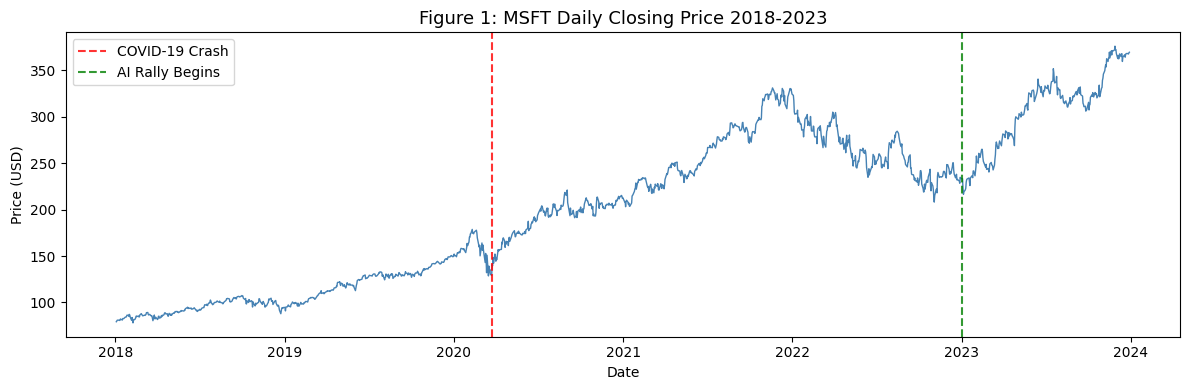

Figure 1 saved


In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['Date'], df['Close'], color='steelblue', linewidth=1)
ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle='--', alpha=0.8, label='COVID-19 Crash')
ax.axvline(pd.Timestamp('2023-01-01'), color='green', linestyle='--', alpha=0.8, label='AI Rally Begins')
ax.set_title('Figure 1: MSFT Daily Closing Price 2018-2023', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig1_msft_price.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

---
## Task 2: State Transition Function and Reward Function

In [4]:
# State definitions — Table II from the report
# s0: price_change >= 0, holding=1  ->  price up,   holding     ->  valid: HOLD, SELL
# s1: price_change >= 0, holding=0  ->  price up,   not holding ->  valid: HOLD, BUY
# s2: price_change <  0, holding=1  ->  price down, holding     ->  valid: HOLD, SELL
# s3: price_change <  0, holding=0  ->  price down, not holding ->  valid: HOLD, BUY

S = ['s0','s1','s2','s3']
A = ['hold','buy','sell']    # action indices: 0=hold  1=buy  2=sell

def get_state(price_change, holding):
    if price_change >= 0 and holding == 1: return 0  # s0
    if price_change >= 0 and holding == 0: return 1  # s1
    if price_change <  0 and holding == 1: return 2  # s2
    if price_change <  0 and holding == 0: return 3  # s3

print('States:', S)
print('Actions:', A)
print()
print('s0: price up,   holding     -> HOLD or SELL')
print('s1: price up,   not holding -> HOLD or BUY')
print('s2: price down, holding     -> HOLD or SELL')
print('s3: price down, not holding -> HOLD or BUY')

States: ['s0', 's1', 's2', 's3']
Actions: ['hold', 'buy', 'sell']

s0: price up,   holding     -> HOLD or SELL
s1: price up,   not holding -> HOLD or BUY
s2: price down, holding     -> HOLD or SELL
s3: price down, not holding -> HOLD or BUY


In [5]:
# Reward matrix — derived from average daily price changes in the dataset
up_days   = df[df['price_change'] >= 0]['price_change']
down_days = df[df['price_change'] <  0]['price_change']
avg_up    = up_days.mean()
avg_down  = down_days.mean()

print(f'Average price change on up days:   {avg_up:.4f}')
print(f'Average price change on down days: {avg_down:.4f}')

# R[state, action]:  columns = [hold, buy, sell]
R = np.full((4, 3), np.nan)
R[0] = [round(avg_up/10, 4),  np.nan,          round(avg_up, 4)   ]  # s0: hold(small reward), sell
R[1] = [0.0,                   0.0,             np.nan             ]  # s1: hold(neutral),  buy(neutral - dont chase)
R[2] = [round(avg_down/10, 4), np.nan,          round(avg_down, 4) ]  # s2: hold(penalty),  sell
R[3] = [0.0,                   round(avg_up, 4), np.nan            ]  # s3: hold(neutral),  buy(rewarded - buy the dip)

R_df = pd.DataFrame(R, index=S, columns=A)
print()
print('Reward Matrix R[state, action]:')
print(R_df.to_string())

Average price change on up days:   2.6729
Average price change on down days: -2.7709

Reward Matrix R[state, action]:
      hold     buy    sell
s0  0.2673     NaN  2.6729
s1  0.0000  0.0000     NaN
s2 -0.2771     NaN -2.7709
s3  0.0000  2.6729     NaN


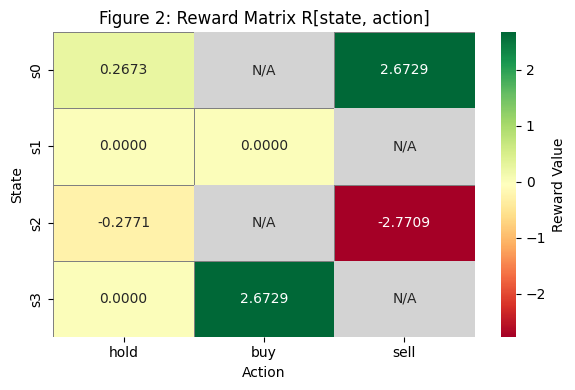

Figure 2 saved


In [6]:
# Figure 2: Reward Matrix Heatmap
R_display = R_df.copy().astype(object)
for i in range(4):
    for j in range(3):
        R_display.iloc[i,j] = 'N/A' if np.isnan(R[i,j]) else f'{R[i,j]:.4f}'
mask = np.isnan(R)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(R, annot=R_display, fmt='', mask=mask, cmap='RdYlGn',
            linewidths=0.5, linecolor='grey', cbar_kws={'label':'Reward Value'},
            xticklabels=A, yticklabels=S, ax=ax)
sns.heatmap(np.where(mask, 0, np.nan), cmap=['#d3d3d3'],
            annot=pd.DataFrame([['N/A' if mask[i,j] else '' for j in range(3)]
                                 for i in range(4)], index=S, columns=A),
            fmt='', cbar=False, xticklabels=A, yticklabels=S, ax=ax)
ax.set_title('Figure 2: Reward Matrix R[state, action]', fontsize=12)
ax.set_xlabel('Action'); ax.set_ylabel('State')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig2_reward_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

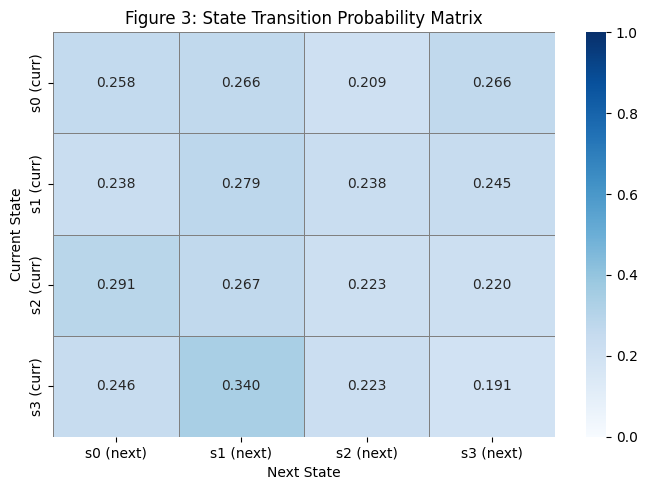

Figure 3 saved


In [7]:
# Figure 3: State Transition Probability Matrix (computed with random policy)
trans_count = np.zeros((4, 4))
holding = 0
for i in range(len(df) - 1):
    pc_today    = df.loc[i,   'price_change']
    pc_tomorrow = df.loc[i+1, 'price_change']
    curr   = get_state(pc_today, holding)
    action = np.random.choice([0,2] if holding==1 else [0,1])
    if action==1: holding=1
    elif action==2: holding=0
    nxt = get_state(pc_tomorrow, holding)
    trans_count[curr, nxt] += 1

row_sums = trans_count.sum(axis=1, keepdims=True)
row_sums[row_sums==0] = 1
trans_prob = trans_count / row_sums

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(trans_prob, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, linecolor='grey',
            xticklabels=[f'{s} (next)' for s in S],
            yticklabels=[f'{s} (curr)' for s in S],
            vmin=0, vmax=1, ax=ax)
ax.set_title('Figure 3: State Transition Probability Matrix', fontsize=12)
ax.set_xlabel('Next State'); ax.set_ylabel('Current State')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig3_transition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')

---
## Task 3: Q-Learning Parameters and Exploration Policies

In [8]:
alpha         = 0.5    # learning rate
gamma         = 0.9    # discount factor
epsilon       = 0.9    # initial exploration rate
epsilon_decay = 0.995  # decay per episode
epsilon_min   = 0.01   # minimum exploration floor
episodes      = 2000
episode_data  = df.tail(300).reset_index(drop=True)  # last 300 days per episode

print(f'alpha (learning rate) : {alpha}')
print(f'gamma (discount)      : {gamma}')
print(f'epsilon (start)       : {epsilon}')
print(f'epsilon decay         : {epsilon_decay}')
print(f'epsilon min           : {epsilon_min}')
print(f'episodes              : {episodes}')
print(f'timesteps per episode : {len(episode_data)}')

alpha (learning rate) : 0.5
gamma (discount)      : 0.9
epsilon (start)       : 0.9
epsilon decay         : 0.995
epsilon min           : 0.01
episodes              : 2000
timesteps per episode : 300


In [9]:
def epsilon_greedy_masked(Q, state, eps, holding):
    """epsilon-greedy with action masking — only valid actions are selected."""
    valid = [0,2] if holding==1 else [0,1]   # hold+sell OR hold+buy
    if np.random.rand() < eps:
        return np.random.choice(valid)
    q_masked = Q[state].copy()
    for a in range(3):
        if a not in valid: q_masked[a] = -np.inf
    return int(np.argmax(q_masked))

def softmax_masked(Q, state, holding, temperature=1.0):
    """Softmax policy with action masking."""
    valid  = [0,2] if holding==1 else [0,1]
    q_vals = np.array([Q[state,a] for a in valid])
    q_vals = q_vals - np.max(q_vals)   # numerical stability
    exp_q  = np.exp(q_vals / temperature)
    probs  = exp_q / exp_q.sum()
    return valid[np.random.choice(len(valid), p=probs)]

print('Exploration policies defined')

Exploration policies defined


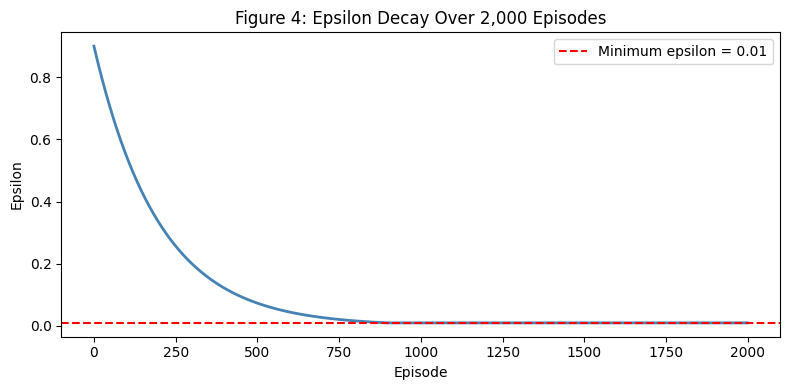

Figure 4 saved


In [10]:
# Figure 4: Epsilon Decay
eps_vals = []
eps_plot = epsilon
for _ in range(episodes):
    eps_vals.append(eps_plot)
    if eps_plot > epsilon_min: eps_plot *= epsilon_decay

plt.figure(figsize=(8, 4))
plt.plot(eps_vals, color='steelblue', linewidth=2)
plt.axhline(epsilon_min, color='red', linestyle='--', linewidth=1.5,
            label=f'Minimum epsilon = {epsilon_min}')
plt.title('Figure 4: Epsilon Decay Over 2,000 Episodes', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Epsilon')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig4_epsilon_decay.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')

---
## Task 4: Run Q-Learning and Represent Performance

In [11]:
def train_qlearning(data, alpha=0.5, gamma=0.9,
                    eps_start=0.9, eps_decay=0.995, eps_min=0.01,
                    n_episodes=2000, policy='epsilon-greedy', temperature=1.0):
    """
    General Q-learning training loop used for all experiments.
    action masking is applied via epsilon_greedy_masked / softmax_masked.
    """
    Q   = np.zeros((4, 3))
    eps = eps_start
    episode_rewards = []

    for ep in range(n_episodes):
        holding = np.random.randint(0, 2)   # random initial holding
        total   = 0.0

        for t in range(len(data) - 1):
            pc    = float(data.loc[t, 'price_change'])
            state = get_state(pc, holding)

            if policy == 'softmax':
                action = softmax_masked(Q, state, holding, temperature)
            else:
                action = epsilon_greedy_masked(Q, state, eps, holding)

            # Execute action
            if action==1 and holding==0: holding=1     # buy
            elif action==2 and holding==1: holding=0   # sell

            reward = R[state, action]
            if np.isnan(reward): reward = 0.0
            total += reward

            next_pc    = float(data.loc[t+1, 'price_change'])
            next_state = get_state(next_pc, holding)
            best_next  = np.nanmax(Q[next_state])

            # Q-update rule
            Q[state, action] += alpha * (reward + gamma*best_next - Q[state, action])

        if eps > eps_min: eps *= eps_decay
        episode_rewards.append(total)

    return Q, episode_rewards

def smooth(values, window=50):
    return np.convolve(values, np.ones(window)/window, mode='valid')

print('Training function defined')

Training function defined


In [12]:
# Train base agent or load from Drive
if os.path.exists(Q_PATH):
    Q = np.load(Q_PATH)
    print('Q-table loaded from Drive. Running episode pass for reward history...')
    _, episode_rewards = train_qlearning(episode_data)
    Q = np.load(Q_PATH)   # keep the saved converged table
else:
    print('Training base Q-learning agent (2000 episodes)...')
    Q, episode_rewards = train_qlearning(episode_data)
    np.save(Q_PATH, Q)
    print('Training complete. Q-table saved to Drive.')

print()
print('Final Q-Table:')
print(pd.DataFrame(np.round(Q, 4), index=S, columns=A))

# Valid actions per state (for correct policy readout)
valid_map = {0:[0,2], 1:[0,1], 2:[0,2], 3:[0,1]}
print()
print('Converged Policy:')
print('-'*35)
for i, s in enumerate(S):
    v    = valid_map[i]
    best = v[int(np.argmax([Q[i,a] for a in v]))]
    print(f'  {s}: {A[best].upper()}')

Q-table loaded from Drive. Running episode pass for reward history...

Final Q-Table:
       hold      buy     sell
s0  11.3663   0.0000  15.4306
s1   8.7155  13.2013   0.0000
s2  14.0729   0.0000   7.5316
s3  12.0959  16.9186   0.0000

Converged Policy:
-----------------------------------
  s0: SELL
  s1: BUY
  s2: HOLD
  s3: BUY


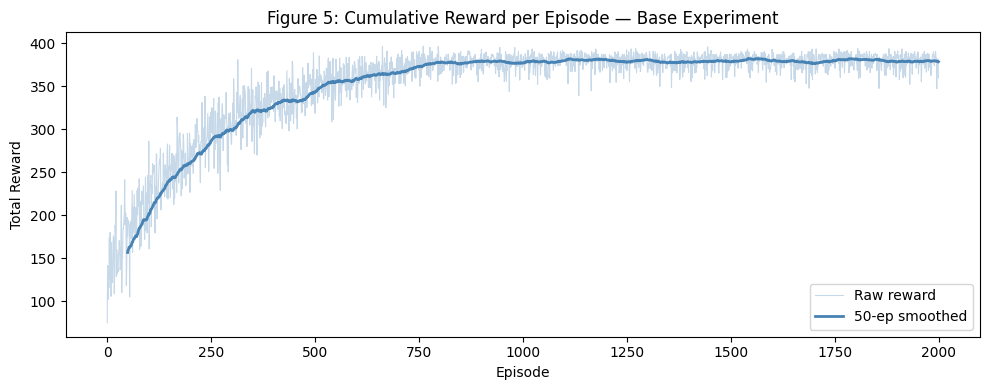

Figure 5 saved


In [13]:
# Figure 5: Cumulative Reward per Episode — Base Experiment
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.3, color='steelblue', linewidth=0.8, label='Raw reward')
plt.plot(np.arange(49, len(episode_rewards)), smooth(episode_rewards),
         color='steelblue', linewidth=2, label='50-ep smoothed')
plt.title('Figure 5: Cumulative Reward per Episode — Base Experiment', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Total Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig5_reward_base.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

---
## Task 5: Repeat with Different Parameter Values and Policies

alpha=0.2  last-100 avg: 381.39
alpha=0.5  last-100 avg: 381.10
alpha=0.9  last-100 avg: 367.44


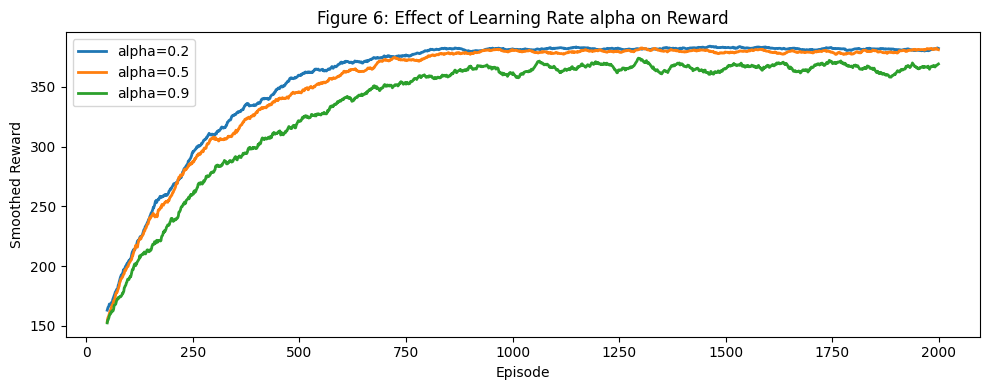

Figure 6 saved


In [14]:
# Alpha sensitivity: alpha in {0.2, 0.5, 0.9}, gamma=0.9 fixed
alpha_results = {}
for a in [0.2, 0.5, 0.9]:
    _, rewards = train_qlearning(episode_data, alpha=a)
    alpha_results[a] = rewards
    print(f'alpha={a}  last-100 avg: {np.mean(rewards[-100:]):.2f}')

plt.figure(figsize=(10, 4))
for a, rewards in alpha_results.items():
    plt.plot(np.arange(49, len(rewards)), smooth(rewards), label=f'alpha={a}', linewidth=2)
plt.title('Figure 6: Effect of Learning Rate alpha on Reward', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig6_alpha.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved')

gamma=0.2  last-100 avg: 381.96
gamma=0.5  last-100 avg: 381.37
gamma=0.9  last-100 avg: 379.76


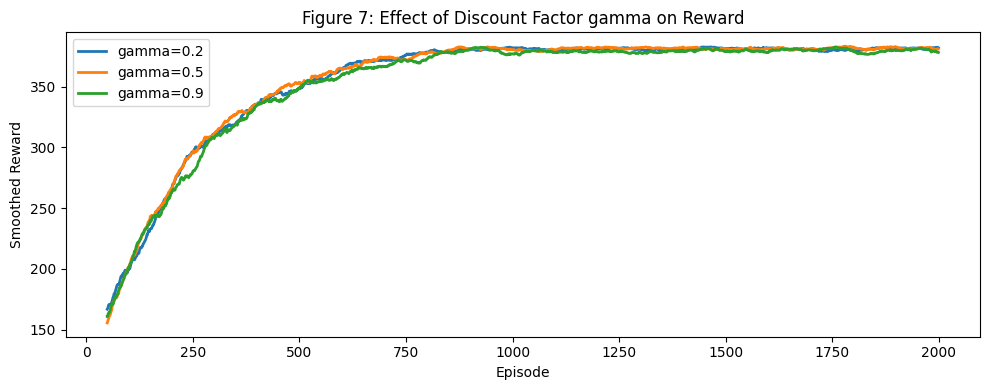

Figure 7 saved


In [15]:
# Gamma sensitivity: gamma in {0.2, 0.5, 0.9}, alpha=0.5 fixed
gamma_results = {}
for g in [0.2, 0.5, 0.9]:
    _, rewards = train_qlearning(episode_data, gamma=g)
    gamma_results[g] = rewards
    print(f'gamma={g}  last-100 avg: {np.mean(rewards[-100:]):.2f}')

plt.figure(figsize=(10, 4))
for g, rewards in gamma_results.items():
    plt.plot(np.arange(49, len(rewards)), smooth(rewards), label=f'gamma={g}', linewidth=2)
plt.title('Figure 7: Effect of Discount Factor gamma on Reward', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig7_gamma.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved')

decay=0.99  last-100 avg: 379.27
decay=0.995  last-100 avg: 378.56
decay=0.999  last-100 avg: 331.74


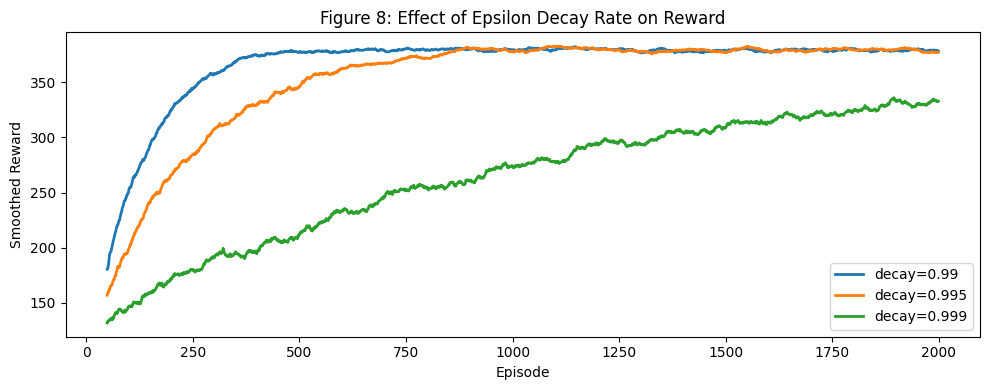

Figure 8 saved


In [16]:
# Epsilon decay sensitivity: decay in {0.99, 0.995, 0.999}
decay_results = {}
for d in [0.99, 0.995, 0.999]:
    _, rewards = train_qlearning(episode_data, eps_decay=d)
    decay_results[d] = rewards
    print(f'decay={d}  last-100 avg: {np.mean(rewards[-100:]):.2f}')

plt.figure(figsize=(10, 4))
for d, rewards in decay_results.items():
    plt.plot(np.arange(49, len(rewards)), smooth(rewards), label=f'decay={d}', linewidth=2)
plt.title('Figure 8: Effect of Epsilon Decay Rate on Reward', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig8_decay.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved')

epsilon-greedy last-100 avg: 378.52
softmax        last-100 avg: 375.42


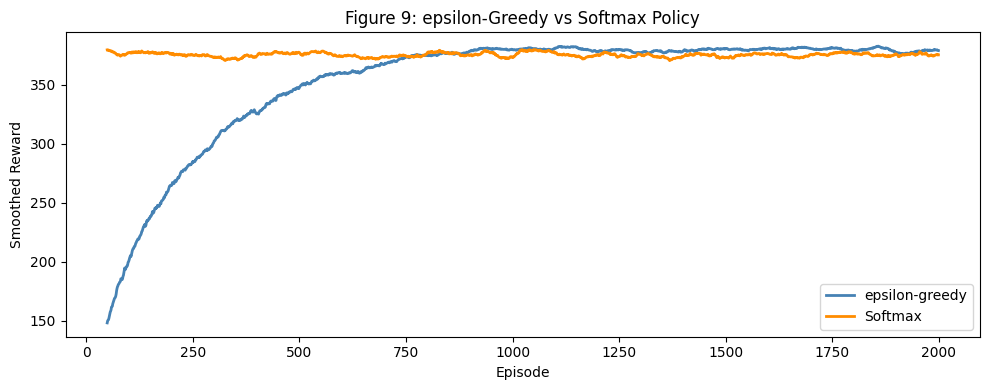

Figure 9 saved


In [17]:
# Policy comparison: epsilon-greedy vs softmax
_, rewards_eg = train_qlearning(episode_data, policy='epsilon-greedy')
_, rewards_sm = train_qlearning(episode_data, policy='softmax')
print(f'epsilon-greedy last-100 avg: {np.mean(rewards_eg[-100:]):.2f}')
print(f'softmax        last-100 avg: {np.mean(rewards_sm[-100:]):.2f}')

plt.figure(figsize=(10, 4))
plt.plot(np.arange(49, len(rewards_eg)), smooth(rewards_eg),
         label='epsilon-greedy', color='steelblue', linewidth=2)
plt.plot(np.arange(49, len(rewards_sm)), smooth(rewards_sm),
         label='Softmax', color='darkorange', linewidth=2)
plt.title('Figure 9: epsilon-Greedy vs Softmax Policy', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig9_policy.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved')

---
## Task 6: Quantitative and Qualitative Analysis

In [18]:
all_results = {
    'Base (a=0.5, g=0.9)' : episode_rewards,
    'a=0.2'               : alpha_results[0.2],
    'a=0.9'               : alpha_results[0.9],
    'g=0.2'               : gamma_results[0.2],
    'g=0.5'               : gamma_results[0.5],
    'decay=0.99'          : decay_results[0.99],
    'decay=0.999'         : decay_results[0.999],
    'Softmax'             : rewards_sm,
}

sm_base   = np.convolve(episode_rewards, np.ones(50)/50, mode='valid')
base_conv = np.mean(sm_base[-50:])
conv_ep   = next((i for i,r in enumerate(sm_base) if r >= 0.95*base_conv), None)

print(f'{"Experiment":<22} {"First100":>10} {"Last100":>10} {"Peak":>10} {"Improv%":>10}')
print('-'*65)
for name, rewards in all_results.items():
    first  = np.mean(rewards[:100])
    last   = np.mean(rewards[-100:])
    peak   = np.max(rewards)
    improv = ((last-first)/abs(first))*100 if first!=0 else 0
    print(f'{name:<22}  {first:>9.2f}  {last:>9.2f}  {peak:>9.2f}  {improv:>9.1f}%')
print(f'\nBase convergence: ~episode {conv_ep}')

Experiment               First100    Last100       Peak    Improv%
-----------------------------------------------------------------
Base (a=0.5, g=0.9)        178.38     378.83     396.62      112.4%
a=0.2                      183.28     381.39     402.04      108.1%
a=0.9                      170.58     367.44     399.59      115.4%
g=0.2                      183.00     381.96     399.31      108.7%
g=0.5                      178.66     381.37     399.76      113.5%
decay=0.99                 215.29     379.27     400.05       76.2%
decay=0.999                139.10     331.74     383.85      138.5%
Softmax                    378.06     375.42     416.01       -0.7%

Base convergence: ~episode 564


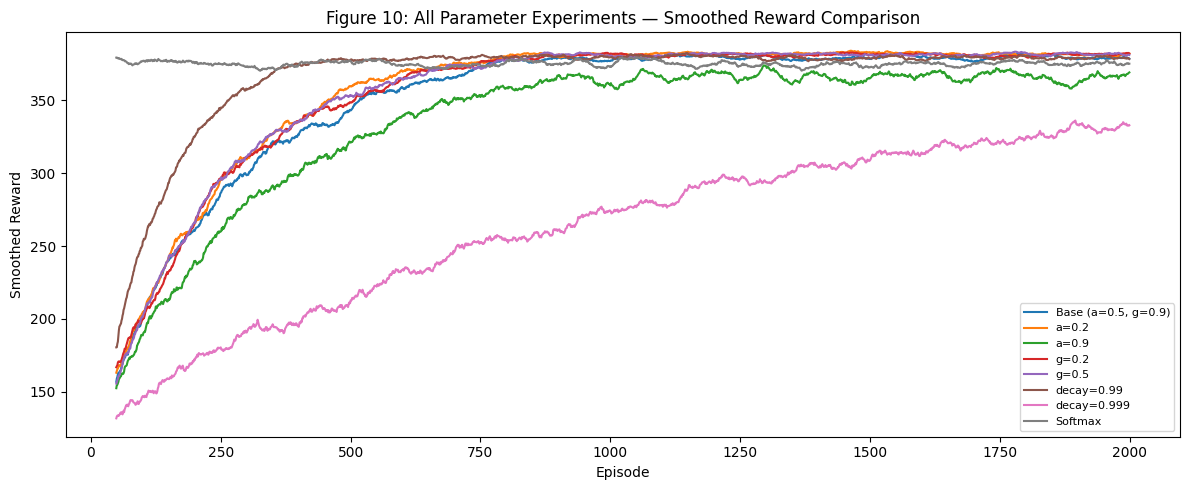

Figure 10 saved


In [19]:
# Figure 10: All experiments on one chart
plt.figure(figsize=(12, 5))
for name, rewards in all_results.items():
    plt.plot(np.arange(49, len(rewards)), smooth(rewards), label=name, linewidth=1.5)
plt.title('Figure 10: All Parameter Experiments — Smoothed Reward Comparison', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig10_all_experiments.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10 saved')

### Agent Visualisation on Test Data

In [20]:
# Test data = all data before the last-300-day training window
test_df = df.iloc[:-300].reset_index(drop=True)
print(f'Test period: {test_df["Date"].iloc[0].date()} to {test_df["Date"].iloc[-1].date()} ({len(test_df)} days)')

initial_balance = 10000.0
balance  = initial_balance
holding  = 0
records  = []
valid_map = {0:[0,2], 1:[0,1], 2:[0,2], 3:[0,1]}

for i in range(len(test_df) - 1):
    pc     = float(test_df.loc[i, 'price_change'])
    price  = float(test_df.loc[i, 'Close'])
    date   = test_df.loc[i, 'Date']
    state  = get_state(pc, holding)
    valid  = valid_map[state]
    action = valid[int(np.argmax([Q[state,a] for a in valid]))]
    aname  = A[action]
    if action==1 and holding==0: holding=1;  balance -= price
    elif action==2 and holding==1: holding=0; balance += price
    portfolio = balance + (price if holding==1 else 0)
    records.append({'date':date, 'price':price, 'action':aname, 'portfolio':round(portfolio,2)})

results_df = pd.DataFrame(records)
total_ret  = results_df['portfolio'].iloc[-1] - initial_balance
print(f'Initial: {initial_balance:,.2f}')
print(f'Final:   {results_df["portfolio"].iloc[-1]:,.2f}')
print(f'Return:  {total_ret:,.2f} ({total_ret/initial_balance*100:.1f}%)')
print(f'Buys: {(results_df["action"]=="buy").sum()}  |  Sells: {(results_df["action"]=="sell").sum()}  |  Holds: {(results_df["action"]=="hold").sum()}')

Test period: 2018-01-03 to 2022-10-19 (1208 days)
Initial: 10,000.00
Final:   10,140.33
Return:  140.33 (1.4%)
Buys: 432  |  Sells: 431  |  Holds: 344


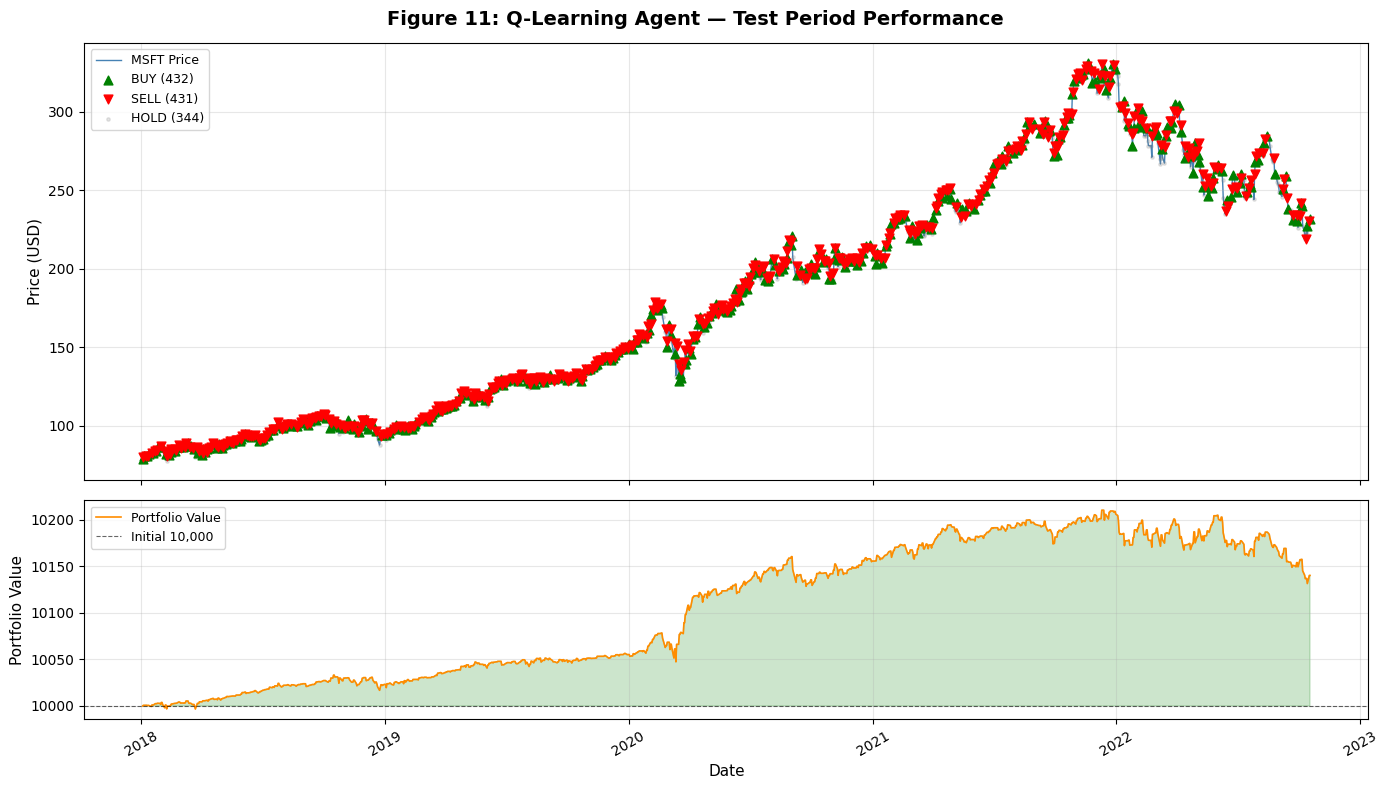

Figure 11 saved


In [21]:
# Figure 11: Price chart with trade markers and portfolio value
buys  = results_df[results_df['action']=='buy']
sells = results_df[results_df['action']=='sell']
holds = results_df[results_df['action']=='hold']

fig,(ax1,ax2) = plt.subplots(2,1,figsize=(14,8),sharex=True,
                              gridspec_kw={'height_ratios':[2,1]})
fig.suptitle('Figure 11: Q-Learning Agent — Test Period Performance',
             fontsize=14, fontweight='bold')

ax1.plot(results_df['date'], results_df['price'],
         color='steelblue', linewidth=1, label='MSFT Price', zorder=1)
ax1.scatter(buys['date'],  buys['price'],  marker='^', color='green',
            s=40, zorder=3, label=f'BUY ({len(buys)})')
ax1.scatter(sells['date'], sells['price'], marker='v', color='red',
            s=40, zorder=3, label=f'SELL ({len(sells)})')
ax1.scatter(holds['date'], holds['price'], marker='o', color='grey',
            s=6,  zorder=2, alpha=0.2, label=f'HOLD ({len(holds)})')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(results_df['date'], results_df['portfolio'],
         color='darkorange', linewidth=1.2, label='Portfolio Value')
ax2.axhline(initial_balance, color='black', linestyle='--',
            linewidth=0.8, alpha=0.6, label=f'Initial {initial_balance:,.0f}')
ax2.fill_between(results_df['date'], results_df['portfolio'], initial_balance,
                 where=results_df['portfolio']>=initial_balance,
                 alpha=0.2, color='green')
ax2.fill_between(results_df['date'], results_df['portfolio'], initial_balance,
                 where=results_df['portfolio']<initial_balance,
                 alpha=0.2, color='red')
ax2.set_ylabel('Portfolio Value', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig11_agent_test.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11 saved')

---
## Task 7: DQN with Two Improvements

**Improvement 1 — Dueling Architecture:** Separates the Q-value into state value V(s) and action advantage A(s,a), so the network learns which states are inherently good independently of which action is taken.

**Improvement 2 — Double DQN:** The online network selects the best next action, the target network evaluates it. This removes the maximisation bias present in vanilla DQN where the same network both selects and evaluates, causing systematic overestimation.

In [22]:
class ReplayMemory:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))
    def sample(self, n):
        return random.sample(self.buffer, n)
    def __len__(self):
        return len(self.buffer)

class DuelingDQN(nn.Module):
    """
    Dueling DQN architecture.
    Q(s,a) = V(s) + A(s,a) - mean(A(s,a))
    The mean subtraction forces identifiability between V and A.
    """
    def __init__(self, input_dim=2, output_dim=3):
        super().__init__()
        self.feature = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU())
        self.value   = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))
        self.adv     = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, output_dim))

    def forward(self, x):
        f = self.feature(x)
        V = self.value(f)
        A = self.adv(f)
        return V + A - A.mean(dim=1, keepdim=True)

class DQNAgent:
    def __init__(self, state_dim=2, action_dim=3, lr=0.001, gamma=0.9,
                 epsilon=0.9, epsilon_decay=0.995, epsilon_min=0.01,
                 batch_size=64, target_update=50):
        self.action_dim    = action_dim
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        self.batch_size    = batch_size
        self.target_update = target_update
        self.steps         = 0
        # Online + target networks (Double DQN)
        self.online_net = DuelingDQN(state_dim, action_dim)
        self.target_net = DuelingDQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory    = ReplayMemory()

    def select_action(self, sv, holding):
        valid = [0,2] if holding==1 else [0,1]
        if random.random() < self.epsilon:
            return random.choice(valid)
        st = torch.FloatTensor(sv).unsqueeze(0)
        with torch.no_grad():
            q = self.online_net(st).squeeze()
        masked = torch.full((self.action_dim,), float('-inf'))
        for a in valid: masked[a] = q[a]
        return int(torch.argmax(masked).item())

    def store(self, *args):
        self.memory.push(*args)

    def train_step(self):
        if len(self.memory) < self.batch_size: return
        s, a, r, ns, d = zip(*self.memory.sample(self.batch_size))
        s  = torch.FloatTensor(s)
        a  = torch.LongTensor(a).unsqueeze(1)
        r  = torch.FloatTensor(r)
        ns = torch.FloatTensor(ns)
        d  = torch.FloatTensor(d)
        curr_q = self.online_net(s).gather(1, a).squeeze()
        with torch.no_grad():
            # Double DQN: online selects action, target evaluates it
            best_a   = self.online_net(ns).argmax(dim=1, keepdim=True)
            target_q = self.target_net(ns).gather(1, best_a).squeeze()
            target_q = r + self.gamma * target_q * (1 - d)
        loss = nn.MSELoss()(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def get_state_vector(price_change, holding):
    """Normalise price_change to ~[-1,1] range, combine with holding flag."""
    return [float(price_change) / 10.0, float(holding)]

print('DQN classes defined')

DQN classes defined


In [28]:
def run_dqn(agent, data, n_episodes, verbose=True):
    rewards = []
    for ep in range(n_episodes):
        holding = random.randint(0, 1)
        total   = 0.0
        for t in range(len(data) - 1):
            pc     = float(data.loc[t, 'price_change'])
            sv     = get_state_vector(pc, holding)
            si     = get_state(pc, holding)            # state BEFORE action — for reward lookup
            action = agent.select_action(sv, holding)

            reward = R[si, action]                     # reward from pre-action state
            if np.isnan(reward): reward = 0.0
            total += reward

            # Now apply the action
            if action==1 and holding==0: holding=1
            elif action==2 and holding==1: holding=0

            next_pc = float(data.loc[t+1, 'price_change'])
            next_sv = get_state_vector(next_pc, holding)
            done    = 1.0 if t == len(data)-2 else 0.0
            agent.store(sv, action, reward, next_sv, done)
            agent.train_step()
        agent.decay_epsilon()
        rewards.append(total)
        if verbose and ep % 50 == 0:
            print(f'  Ep {ep:>4} | Reward: {total:>8.2f} | epsilon: {agent.epsilon:.4f}')
    return rewards

# Train DQN or load from Drive
dqn_episodes = 2000   # ← match Q-learning episode count for fair comparison

if os.path.exists(DQN_PATH):
    print('DQN weights found on Drive — deleting to retrain with fixed code.')
    os.remove(DQN_PATH) #onetime use to retrain weights on new reward signal

print(f'Training DQN ({dqn_episodes} episodes)...')
agent       = DQNAgent()
dqn_rewards = run_dqn(agent, episode_data, dqn_episodes, verbose=True)
torch.save(agent.online_net.state_dict(), DQN_PATH)
print('DQN training complete. Weights saved to Drive.')

Training DQN (2000 episodes)...
  Ep    0 | Reward:   126.81 | epsilon: 0.8955
  Ep   50 | Reward:   149.43 | epsilon: 0.6970
  Ep  100 | Reward:   213.68 | epsilon: 0.5425
  Ep  150 | Reward:   286.13 | epsilon: 0.4222
  Ep  200 | Reward:   321.04 | epsilon: 0.3286
  Ep  250 | Reward:   355.47 | epsilon: 0.2558
  Ep  300 | Reward:   348.75 | epsilon: 0.1991
  Ep  350 | Reward:   379.45 | epsilon: 0.1549
  Ep  400 | Reward:   352.36 | epsilon: 0.1206
  Ep  450 | Reward:   379.98 | epsilon: 0.0939
  Ep  500 | Reward:   381.38 | epsilon: 0.0730
  Ep  550 | Reward:   411.08 | epsilon: 0.0569
  Ep  600 | Reward:   390.15 | epsilon: 0.0443
  Ep  650 | Reward:   394.30 | epsilon: 0.0344
  Ep  700 | Reward:   395.98 | epsilon: 0.0268
  Ep  750 | Reward:   404.09 | epsilon: 0.0209
  Ep  800 | Reward:   413.60 | epsilon: 0.0162
  Ep  850 | Reward:   393.30 | epsilon: 0.0126
  Ep  900 | Reward:   413.22 | epsilon: 0.0100
  Ep  950 | Reward:   418.40 | epsilon: 0.0100
  Ep 1000 | Reward:   408.70

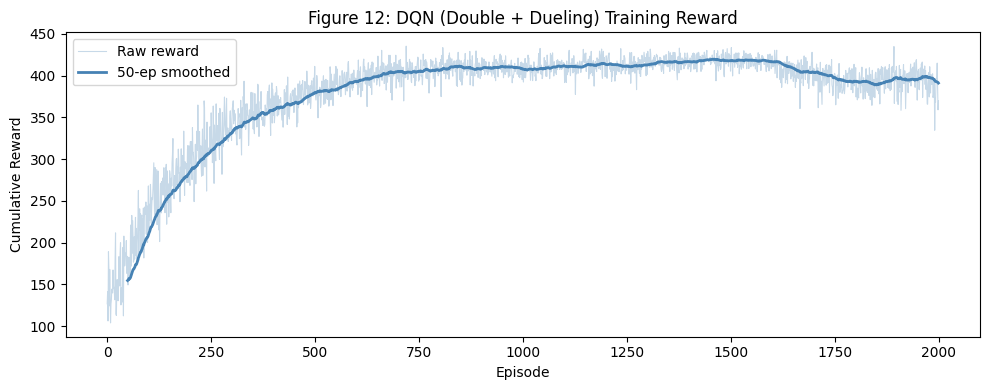

Figure 12 saved


In [29]:
# Figure 12: DQN Training Reward
plt.figure(figsize=(10, 4))
plt.plot(dqn_rewards, alpha=0.3, color='steelblue', linewidth=0.8, label='Raw reward')
if len(dqn_rewards) >= 50:
    plt.plot(np.arange(49, len(dqn_rewards)), smooth(dqn_rewards),
             color='steelblue', linewidth=2, label='50-ep smoothed')
plt.title('Figure 12: DQN (Double + Dueling) Training Reward', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Cumulative Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig12_dqn_reward.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 12 saved')

---
## Task 8: Quantitative and Qualitative Analysis of DQN Results

In [30]:
def summarise(rewards, name):
    first  = np.mean(rewards[:100])
    last   = np.mean(rewards[-100:])
    peak   = np.max(rewards)
    peak_e = int(np.argmax(rewards))
    improv = ((last-first)/abs(first))*100 if first!=0 else 0
    sm     = np.convolve(rewards, np.ones(50)/50, mode='valid')
    conv   = next((i for i,r in enumerate(sm) if r >= 0.90*np.mean(sm[-50:])), None)
    print(f'--- {name} ---')
    print(f'  First-100 avg : {first:.2f}')
    print(f'  Last-100 avg  : {last:.2f}')
    print(f'  Peak reward   : {peak:.2f} (episode {peak_e})')
    print(f'  Convergence   : ~episode {conv}')
    print(f'  Improvement   : {improv:.1f}%')
    return dict(first=first, last=last, peak=peak, conv=conv, improv=improv)

ql_stats  = summarise(episode_rewards, 'Q-Learning (Base)')
print()
dqn_stats = summarise(dqn_rewards,     'DQN (Double + Dueling)')

--- Q-Learning (Base) ---
  First-100 avg : 178.38
  Last-100 avg  : 378.83
  Peak reward   : 396.62 (episode 760)
  Convergence   : ~episode 439
  Improvement   : 112.4%

--- DQN (Double + Dueling) ---
  First-100 avg : 182.03
  Last-100 avg  : 393.24
  Peak reward   : 435.33 (episode 719)
  Convergence   : ~episode 341
  Improvement   : 116.0%


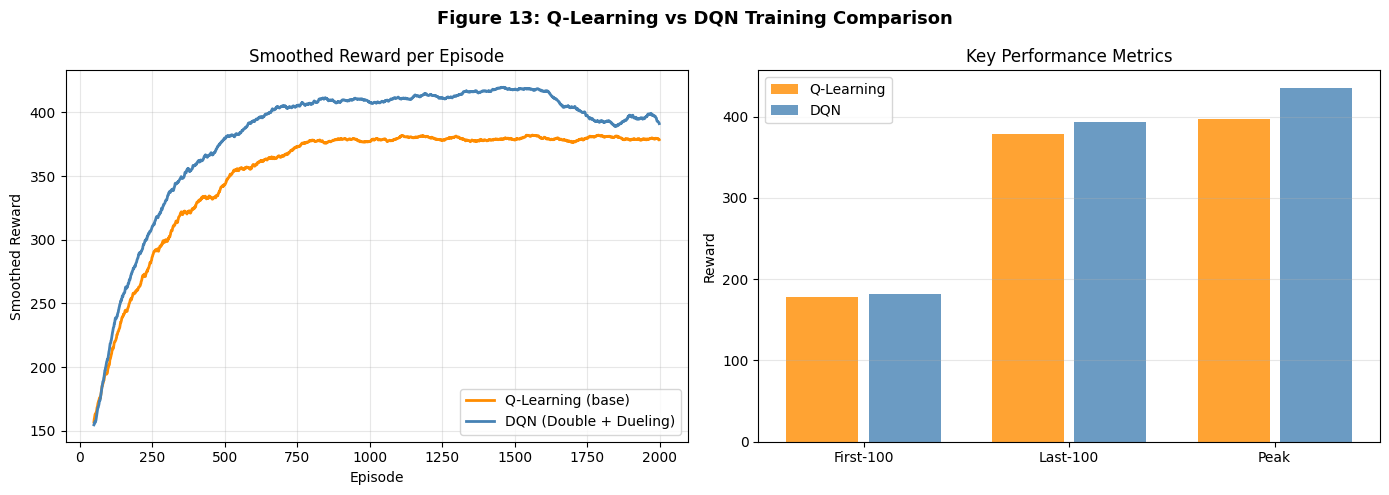

Figure 13 saved

All figures saved to: /content/drive/MyDrive/DRL_CW
Files: ['DRL_QTrade_Clean.ipynb', 'q_table_base.npy', 'fig1_msft_price.png', 'fig2_reward_matrix.png', 'fig3_transition.png', 'fig4_epsilon_decay.png', 'fig5_reward_base.png', 'fig6_alpha.png', 'fig7_gamma.png', 'fig8_decay.png', 'fig9_policy.png', 'fig10_all_experiments.png', 'fig11_agent_test.png', 'fig12_dqn_reward.png', 'fig13_ql_vs_dqn.png', 'dqn_weights.pth']


In [31]:
# Figure 13: Q-Learning vs DQN comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 13: Q-Learning vs DQN Training Comparison',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(np.arange(49, len(episode_rewards)), smooth(episode_rewards),
        color='darkorange', linewidth=2, label='Q-Learning (base)')
ax.plot(np.arange(49, len(dqn_rewards)), smooth(dqn_rewards),
        color='steelblue', linewidth=2, label='DQN (Double + Dueling)')
ax.set_title('Smoothed Reward per Episode')
ax.set_xlabel('Episode'); ax.set_ylabel('Smoothed Reward')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
metrics  = ['First-100', 'Last-100', 'Peak']
ql_vals  = [ql_stats['first'],  ql_stats['last'],  ql_stats['peak']]
dqn_vals = [dqn_stats['first'], dqn_stats['last'], dqn_stats['peak']]
x = np.arange(len(metrics))
ax2.bar(x-0.2, ql_vals,  0.35, label='Q-Learning', color='darkorange', alpha=0.8)
ax2.bar(x+0.2, dqn_vals, 0.35, label='DQN',        color='steelblue',  alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(metrics)
ax2.set_title('Key Performance Metrics')
ax2.set_ylabel('Reward')
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig13_ql_vs_dqn.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 13 saved')
print()
print(f'All figures saved to: {SAVE_DIR}')
print(f'Files: {os.listdir(SAVE_DIR)}')